# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1555s 9us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

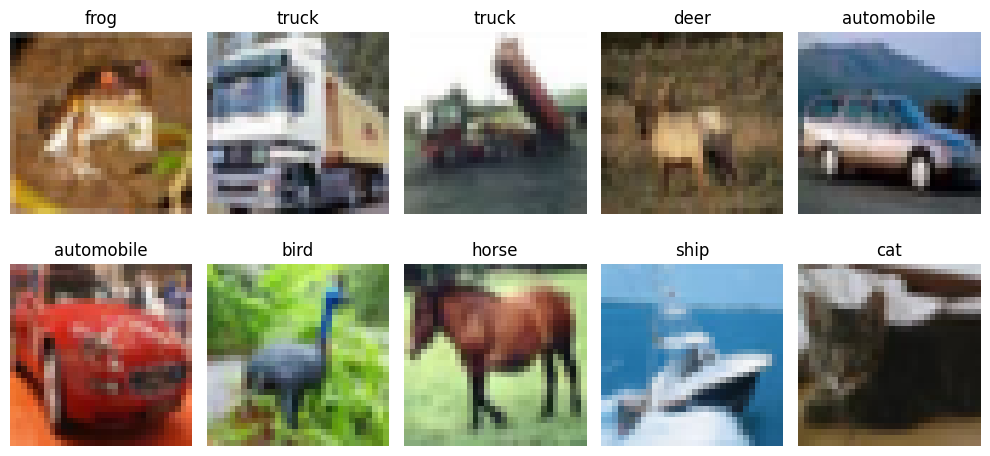

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2654 - loss: 1.9939 - val_accuracy: 0.3140 - val_loss: 1.8809
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3034 - loss: 1.8892 - val_accuracy: 0.3576 - val_loss: 1.8070
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3287 - loss: 1.8323 - val_accuracy: 0.3802 - val_loss: 1.7561
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3409 - loss: 1.8023 - val_accuracy: 0.3766 - val_loss: 1.7441
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3552 - loss: 1.7711 - val_accuracy: 0.3814 - val_loss: 1.7311
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3635 - loss: 1.7531 - val_accuracy: 0.3716 - val_loss: 1.7642
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3678 - loss: 1.7408 - val_accuracy: 0.4044 - val_loss: 1.7008
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3751 - loss: 1.7254 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4178 - loss: 1.6535
ANN Test Accuracy: 0.41780000925064087


In [12]:
ann_model_1 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model_1.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.2516 - loss: 2.0328 - val_accuracy: 0.3340 - val_loss: 1.8600
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.3104 - loss: 1.8954 - val_accuracy: 0.3392 - val_loss: 1.8593
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.3300 - loss: 1.8446 - val_accuracy: 0.3698 - val_loss: 1.7668
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3416 - loss: 1.8062 - val_accuracy: 0.3782 - val_loss: 1.7478
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3576 - loss: 1.7756 - val_accuracy: 0.3902 - val_loss: 1.7265
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.3647 - loss: 1.7543 - val_accuracy: 0.3972 - val_loss: 1.6944
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3725 - loss: 1.7371 - val_accuracy: 0.4128 - val_loss: 1.6983
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3796 - loss: 1.7189 - 

In [13]:
ann_test_loss, ann_test_acc = ann_model_1.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4278 - loss: 1.6143
ANN Test Accuracy: 0.4277999997138977


In [14]:
ann_model_2 = models.Sequential([
    layers.Dense(2048, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model_2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 132ms/step - accuracy: 0.2172 - loss: 2.0890 - val_accuracy: 0.3252 - val_loss: 1.9000
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 130ms/step - accuracy: 0.2929 - loss: 1.9122 - val_accuracy: 0.3276 - val_loss: 1.8556
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.3164 - loss: 1.8630 - val_accuracy: 0.3576 - val_loss: 1.7883
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.3274 - loss: 1.8352 - val_accuracy: 0.3522 - val_loss: 1.7931
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 123ms/step - accuracy: 0.3360 - loss: 1.8170 - val_accuracy: 0.3562 - val_loss: 1.7900
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 123ms/step - accuracy: 0.3480 - loss: 1.7940 - val_accuracy: 0.3790 - val_loss: 1.7431
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 127ms/step - accuracy: 0.3517 - loss: 1.7798 - val_accuracy: 0.3938 - val_loss: 1.7155
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.3601 - lo

In [15]:
ann_test_loss, ann_test_acc = ann_model_2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4110 - loss: 1.6813
ANN Test Accuracy: 0.41100001335144043


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 123ms/step - accuracy: 0.4665 - loss: 1.4926 - val_accuracy: 0.4728 - val_loss: 1.5771
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.6095 - loss: 1.1182 - val_accuracy: 0.5338 - val_loss: 1.3622
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.6720 - loss: 0.9468 - val_accuracy: 0.6166 - val_loss: 1.1206
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7102 - loss: 0.8331 - val_accuracy: 0.6564 - val_loss: 1.0504
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7374 - loss: 0.7441 - val_accuracy: 0.6664 - val_loss: 1.0043
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.7653 - loss: 0.6669 - val_accuracy: 0.7328 - val_loss: 0.8091
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.7908 - loss: 0.5980 - val_accuracy: 0.7304 - val_loss: 0.7912
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.8132 - loss

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7005 - loss: 1.0079
CNN Test Accuracy: 0.7005000114440918


In [18]:
cnn_model_1 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model_1.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 207ms/step - accuracy: 0.4580 - loss: 1.5115 - val_accuracy: 0.5276 - val_loss: 1.3130
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 203ms/step - accuracy: 0.6026 - loss: 1.1361 - val_accuracy: 0.6000 - val_loss: 1.1249
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 203ms/step - accuracy: 0.6632 - loss: 0.9615 - val_accuracy: 0.5870 - val_loss: 1.2140
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 207ms/step - accuracy: 0.7093 - loss: 0.8398 - val_accuracy: 0.6226 - val_loss: 1.1226
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 205ms/step - accuracy: 0.7392 - loss: 0.7450 - val_accuracy: 0.5574 - val_loss: 1.4259
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.7632 - loss: 0.6683 - val_accuracy: 0.6760 - val_loss: 0.9397
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.7899 - loss: 0.5935 - val_accuracy: 0.6038 - val_loss: 1.5012
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 203ms/step - accuracy: 0.8084 -

In [19]:
cnn_test_loss, cnn_test_acc = cnn_model_1.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7118 - loss: 0.9853
CNN Test Accuracy: 0.7117999792098999


In [20]:
cnn_model_2 = models.Sequential([
    layers.Conv2D(128, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model_2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 371ms/step - accuracy: 0.4492 - loss: 1.5329 - val_accuracy: 0.5804 - val_loss: 1.2271
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 368ms/step - accuracy: 0.5924 - loss: 1.1610 - val_accuracy: 0.5416 - val_loss: 1.2586
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 367ms/step - accuracy: 0.6567 - loss: 0.9824 - val_accuracy: 0.6794 - val_loss: 0.9283
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 379ms/step - accuracy: 0.7022 - loss: 0.8548 - val_accuracy: 0.5306 - val_loss: 1.4661
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 371ms/step - accuracy: 0.7355 - loss: 0.7614 - val_accuracy: 0.7270 - val_loss: 0.8116
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 375ms/step - accuracy: 0.7652 - loss: 0.6756 - val_accuracy: 0.6980 - val_loss: 0.8802
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 370ms/step - accuracy: 0.7839 - loss: 0.6200 - val_accuracy: 0.6596 - val_loss: 1.0863
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 372ms/step - accuracy: 0.8047 -

In [21]:
cnn_test_loss, cnn_test_acc = cnn_model_2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7268 - loss: 0.9249
CNN Test Accuracy: 0.7268000245094299


In [22]:
cnn_model_3 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model_3.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 126ms/step - accuracy: 0.4563 - loss: 1.5237 - val_accuracy: 0.5560 - val_loss: 1.2470
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.5992 - loss: 1.1427 - val_accuracy: 0.6290 - val_loss: 1.0590
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.6634 - loss: 0.9675 - val_accuracy: 0.6384 - val_loss: 1.0416
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7053 - loss: 0.8505 - val_accuracy: 0.6396 - val_loss: 1.0407
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7368 - loss: 0.7558 - val_accuracy: 0.6254 - val_loss: 1.1397
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 125ms/step - accuracy: 0.7625 - loss: 0.6765 - val_accuracy: 0.6704 - val_loss: 0.9837
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.7858 - loss: 0.6101 - val_accuracy: 0.7202 - val_loss: 0.8331
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 123ms/step - accuracy: 0.8064 - loss:

In [23]:
cnn_test_loss, cnn_test_acc = cnn_model_3.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7143 - loss: 1.3368
CNN Test Accuracy: 0.7142999768257141


## 📈 Compare Learning Curves

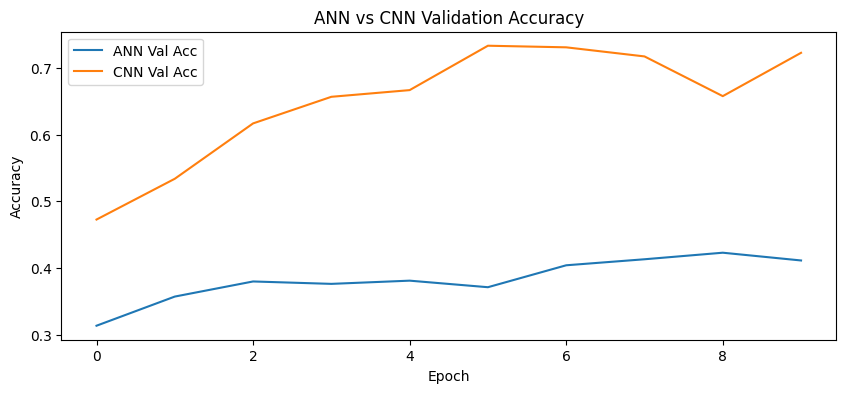

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])


aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 52ms/step - accuracy: 0.3772 - loss: 1.6981 - val_accuracy: 0.4972 - val_loss: 1.3825
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 52ms/step - accuracy: 0.4770 - loss: 1.4529 - val_accuracy: 0.5356 - val_loss: 1.3019
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 52ms/step - accuracy: 0.5121 - loss: 1.3652 - val_accuracy: 0.5934 - val_loss: 1.1417
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5355 - loss: 1.3105 - val_accuracy: 0.5842 - val_loss: 1.1398
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.5490 - loss: 1.2731 - val_accuracy: 0.5970 - val_loss: 1.1649
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.5627 - loss: 1.2398 - val_accuracy: 0.6248 - val_loss: 1.0623
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5706 - loss: 1.2200 - val_accuracy: 0.6288 - val_loss: 1.0378
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5772 -

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 124ms/step - accuracy: 0.4632 - loss: 1.4992 - val_accuracy: 0.5318 - val_loss: 1.2868
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 121ms/step - accuracy: 0.6025 - loss: 1.1378 - val_accuracy: 0.5982 - val_loss: 1.1452
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6693 - loss: 0.9563 - val_accuracy: 0.6660 - val_loss: 0.9668
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7082 - loss: 0.8355 - val_accuracy: 0.6534 - val_loss: 1.0290
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7426 - loss: 0.7385 - val_accuracy: 0.7138 - val_loss: 0.8436
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7675 - loss: 0.6659 - val_accuracy: 0.6988 - val_loss: 0.9106
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7918 - loss: 0.5915 - val_accuracy: 0.7506 - val_loss: 0.7535
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.8098 - loss:

In [25]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7299 - loss: 0.8006
CNN Test Accuracy: 0.7299000024795532


# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4178
1,CNN,0.7005


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**